# 数据简单探查

## 读取数据

In [34]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import title
from numpy.f2py.crackfortran import ignorecontains
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder



# 注意：test.csv本身无Survived列，gender_submission.csv是提交示例，若仅做预测可不用y_test
train_df = pd.read_csv('train.csv')
x_test = pd.read_csv('test.csv')

# 若需评估，可将train_df拆分训练集和验证集，而非直接用gender_submission
# 此处暂时注释y_test相关，若有验证集需求可自行拆分
df = pd.read_csv('gender_submission.csv')
y_test = df['Survived']
y_train=train_df['Survived']



## 数据探查

In [35]:
print('训练集大致情况:')
train_df.info()
print('测试集大致情况:')
x_test.info()


训练集大致情况:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Ticket       891 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
测试集大致情况:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int

# 各特征与Survived关系并进行可视化

## embarked与survival关系

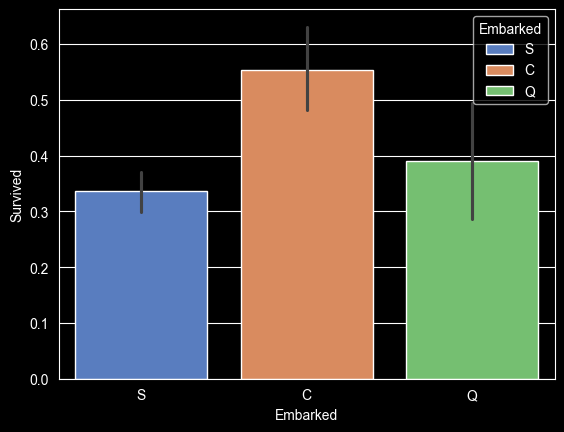

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [36]:
import seaborn as sns
sns.barplot(x='Embarked', y='Survived', data=train_df,hue='Embarked',palette='muted')
plt.show()
#使用众数填充缺失值
print(train_df['Embarked'].value_counts())
train_df['Embarked']=train_df['Embarked'].fillna('S')


## sex与survival关系

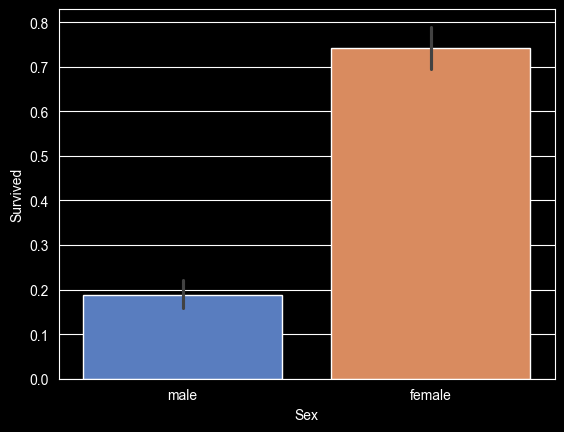

In [37]:
import seaborn as sns
sns.barplot(x='Sex', y='Survived', data=train_df,hue='Sex',palette='muted')
plt.show()

## Parch与survival关系

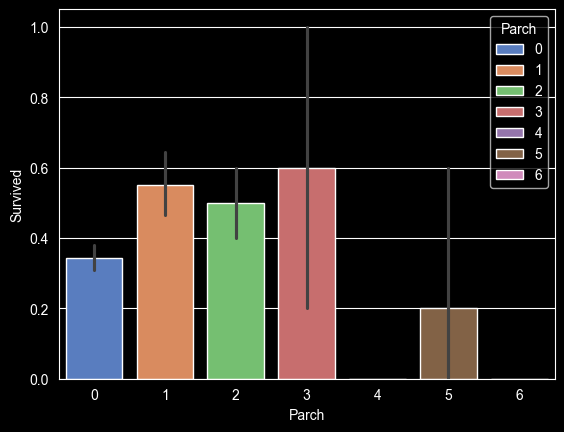

In [38]:
import seaborn as sns
sns.barplot(x='Parch', y='Survived', data=train_df,hue='Parch',palette='muted')
plt.show()

## SibSp与survival关系

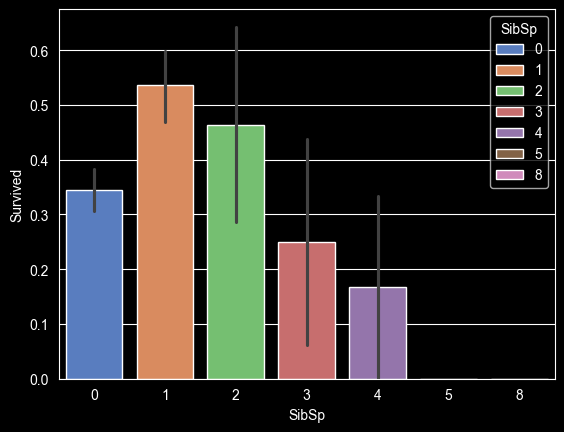

In [39]:
import seaborn as sns
sns.barplot(x='SibSp', y='Survived', data=train_df,hue='SibSp',palette='muted')
plt.show()

## Pclass与survival关系

C:\Users\lijia\AppData\Local\Temp\ipykernel_38212\1844139855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=train_df,palette='muted')


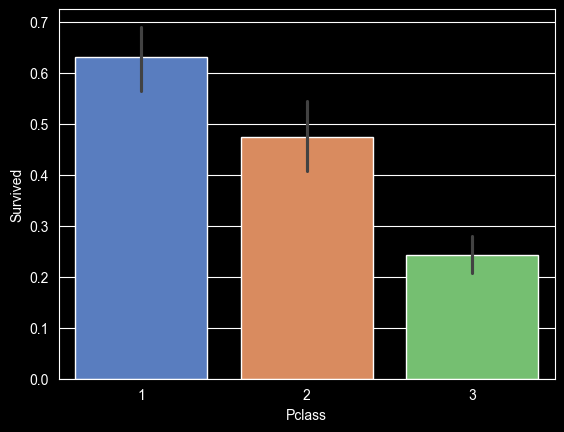

In [40]:
import seaborn as sns
sns.barplot(x='Pclass', y='Survived', data=train_df,palette='muted')
plt.show()

## Fare与survival关系

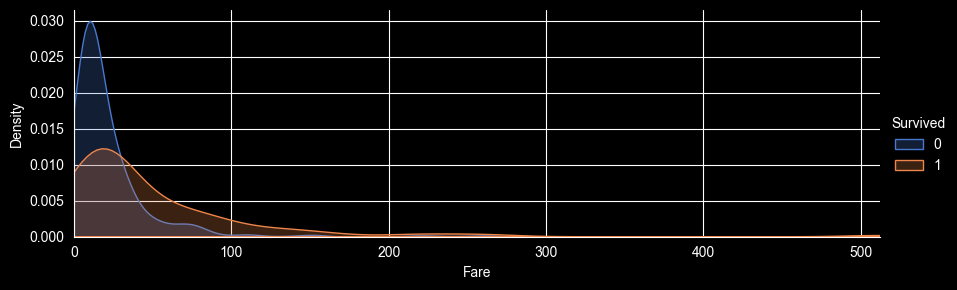

In [41]:
import seaborn as sns
agefacet=sns.FacetGrid(train_df,hue='Survived',aspect=3,palette='muted')
agefacet.map(sns.kdeplot,'Fare',fill=True)
agefacet.set(xlim=(0,512))
agefacet.add_legend()


## Age与survival关系

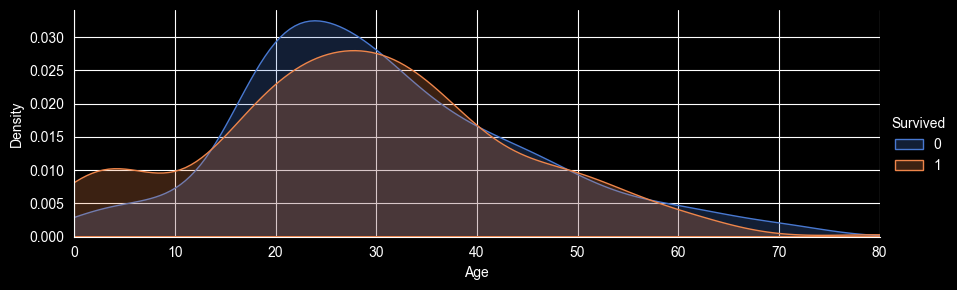

In [42]:
#Age特征处理
#1、age与survived的关系
import seaborn as sns
agefacet=sns.FacetGrid(train_df,hue='Survived',aspect=3,palette='muted')
agefacet.map(sns.kdeplot,'Age',fill=True)
agefacet.set(xlim=(0,80))
agefacet.add_legend()

# 特征工程

## Cabin特征处理

### cabin填充缺失值

C:\Users\lijia\AppData\Local\Temp\ipykernel_38212\3366132545.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Deck', y='Survived', data=train_df,palette='muted')


<Axes: xlabel='Deck', ylabel='Survived'>

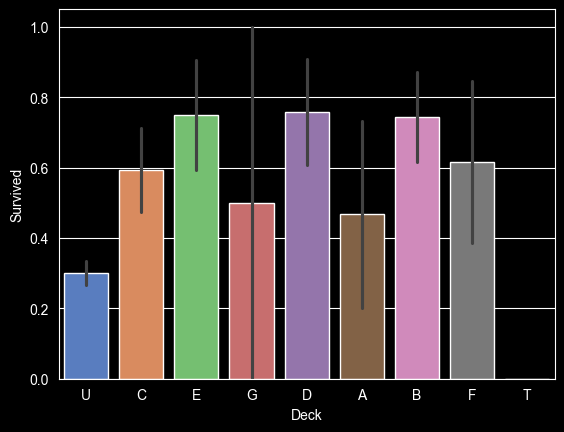

In [43]:
x_test['Cabin']=x_test['Cabin'].fillna('U')
train_df['Cabin']=train_df['Cabin'].fillna('U')
#提取cabin首字母(船舱的类型）
x_test['Deck']=x_test['Cabin'].map(lambda x:x[0])
train_df['Deck']=train_df['Cabin'].map(lambda x:x[0])
#查看不同cabin首字母与survived关系
sns.barplot(x='Deck', y='Survived', data=train_df,palette='muted')

### 根据首字母创建新特征，并为其赋值（具有一定线性关系）

In [44]:

#根据数值分布输出数字,
def classifier(x):
    known_decks=['U','C','E','G','D','A','B','F','T']
    if x not in known_decks:
        return -1       #防止测试集中出现未知值
    elif x in ['E','D','B']:
        return 2
    elif x in ['C','F']:
        return 1
    else:
        return 0

train_df['Deck']=train_df['Deck'].map(classifier).astype('int')
x_test['Deck']=x_test['Deck'].map(classifier).astype('int')
print(train_df['Deck'].value_counts())
print(x_test['Deck'].value_counts())

Deck
0    707
2    112
1     72
Name: count, dtype: int64
Deck
0    335
1     43
2     40
Name: count, dtype: int64


## 新建Famliy Size特征

Family Size
1    549
2    292
0     50
Name: count, dtype: int64
Family Size
1    257
2    145
0     16
Name: count, dtype: int64


C:\Users\lijia\AppData\Local\Temp\ipykernel_38212\2495087752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Family Size', y='Survived', data=train_df,palette='muted')


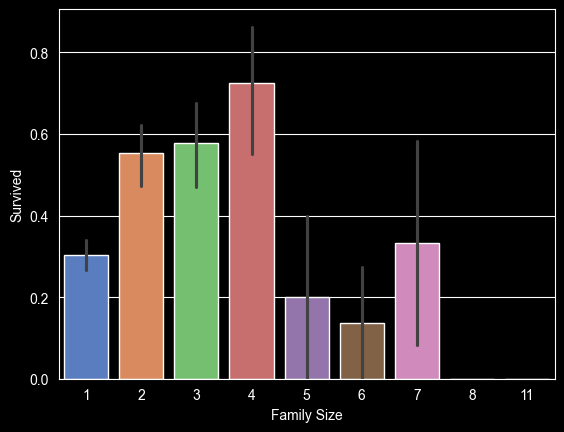

In [45]:
train_df['Family Size']=train_df['Parch']+train_df['SibSp']+1    #加一等于把自己算上
x_test['Family Size']=x_test['Parch']+x_test['SibSp']+1
#查看家庭成员数量与survived关系
sns.barplot(x='Family Size', y='Survived', data=train_df,palette='muted')
#根据家庭数目大小创建新特征与存活率成正相关(小（0),中（1），大（2）），避免数据维度过大
def family_size(x):
    konws_size=[1,2,3,4,5,6,7,8,11]
    if x not in konws_size:
        return -1
    elif x in [5,6,8,11]:
        return 0
    elif x in [1,7]:
        return 1
    else:
        return 2
    return family_size(x)
train_df['Family Size']=train_df['Family Size'].map(family_size)
x_test['Family Size']=x_test['Family Size'].map(family_size)
print(train_df['Family Size'].value_counts())
print(x_test['Family Size'].value_counts())

### Fare缺失值处理

## Fare特征处理

C:\Users\lijia\AppData\Local\Temp\ipykernel_38212\3084931590.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fare_bins', y='Survived', data=train_df,palette='muted')


<Axes: xlabel='Fare_bins', ylabel='Survived'>

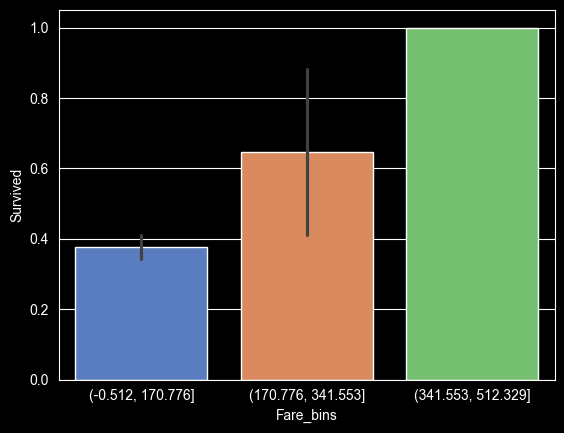

In [46]:
#fare缺失值过小,查看与survived关系
#先对fare做初步数据分箱后绘图(多试几次划分数量以确定更清晰的梯度差异）
train_df['Fare_bins']=pd.cut(train_df['Fare'],bins=3)
x_test['Fare_bins']=pd.cut(x_test['Fare'],bins=3)
sns.barplot(x='Fare_bins', y='Survived', data=train_df,palette='muted')



In [47]:
#查看缺失个体相关的信息
display(train_df[train_df['Fare'].isnull()])
display(x_test[x_test['Fare'].isnull()])
#利用船舱等级，登船口，性别，仓位未知的旅客的平均票价进行填充
price=train_df[(train_df['Pclass']==3)&(train_df['Embarked']=='S')&(train_df['Sex']=='male')&(train_df['Cabin']=='U')]['Fare'].mean()
x_test['Fare']=x_test['Fare'].fillna(price)


,PassengerId,Pclass,Survived,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Ticket,Embarked,Deck,Family Size,Fare_bins


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Family Size,Fare_bins
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,U,S,0,1,NaN


### Fare特征缩放

In [48]:
#根据大致分布分为3部分，低消费（0），中消费（1），高消费（2）（与存活率成正相关）
def fare_size(x):
    if x<170.776:
        return 0
    elif 170.776<=x<=341.553:
        return 1
    else:
        return 2
    return fare_size(x)
train_df['Fare']=train_df['Fare'].map(fare_size).astype('int')
x_test['Fare']=x_test['Fare'].map(fare_size).astype('int')

## Ticket特征处理

### Ticket特征处理

In [49]:
#提取各票号的乘客数量
Ticket_count=train_df['Ticket'].value_counts()
Ticket_count.head(5)

Ticket
347082      7
1601        7
CA. 2343    7
3101295     6
CA 2144     6
Name: count, dtype: int64

### 创建新特征TicketCom

C:\Users\lijia\AppData\Local\Temp\ipykernel_38212\1396249797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TicketCom', y='Survived', data=train_df,palette='muted')


<Axes: xlabel='TicketCom', ylabel='Survived'>

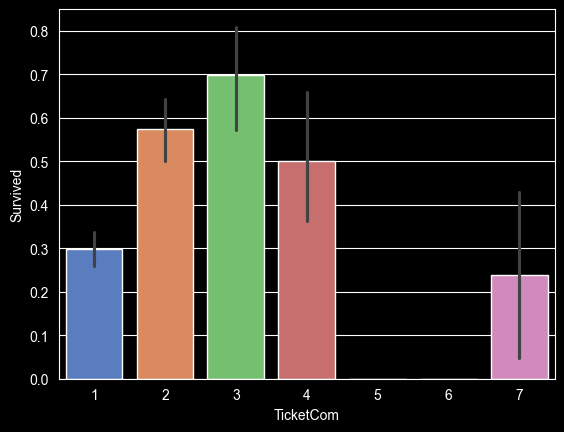

In [50]:
#根据相同票号的乘客数量创建新特征
train_df['TicketCom']=train_df['Ticket'].map(Ticket_count)
#测试集映射，用1填充训练集未出现的票号，表示独票
x_test['TicketCom']=x_test['Ticket'].map(Ticket_count).fillna(1)
#查看新建特征与survival关系，方便后续缩放
sns.barplot(x='TicketCom', y='Survived', data=train_df,palette='muted')


### TicketCom特征缩放

In [51]:
#根据生还率缩放数据，使其具有一定线性关系
def ticket_size(x):
    if x in [1,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]:  #极低生还
        return 0
    elif x in [2,4]:    #中生还率
        return 1
    else:                #高生还率
        return 2
    return ticket_size(x)
train_df['TicketCom']=train_df['TicketCom'].map(ticket_size)
x_test['TicketCom']=x_test['TicketCom'].map(ticket_size)
print(train_df['TicketCom'].value_counts())

TicketCom
0    596
1    232
2     63
Name: count, dtype: int64


## Name特征处理

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


C:\Users\lijia\AppData\Local\Temp\ipykernel_38212\3249758025.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Title', y='Survived', data=train_df,palette='muted')


<Axes: xlabel='Title', ylabel='Survived'>

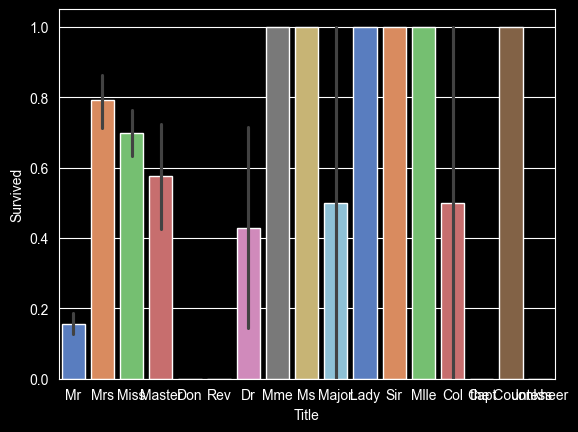

In [52]:
#Name特征处理
#取出头衔
train_df['Title']=train_df['Name'].map(lambda x:x.split(',')[1].split('.')[0].strip())
x_test['Title']=x_test['Name'].map(lambda x:x.split(',')[1].split('.')[0].strip())
print(train_df['Title'].value_counts())
#查看头衔与存活率关系
sns.barplot(x='Title', y='Survived', data=train_df,palette='muted')

C:\Users\lijia\AppData\Local\Temp\ipykernel_38212\376734384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Title', y='Survived', data=train_df,palette='muted')


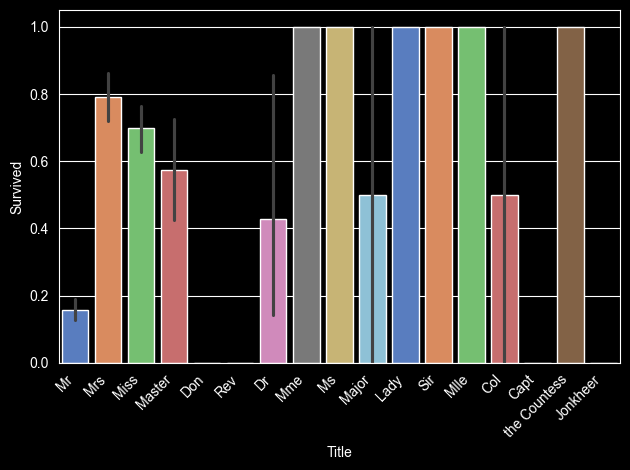

In [53]:
#头衔名称较长且数量多，旋转标签避免重叠，提升可读性
sns.barplot(x='Title', y='Survived', data=train_df,palette='muted')
plt.xticks(rotation=45, ha='right')     #右转45度，右对齐
plt.tight_layout()      #自动调整布局，防止标签别截断
plt.show()

In [54]:
#根据存活率重新进行分类
def title_classifier(x):
    konws_title=['Mr','Mrs','Miss','Master','Dr','Rev','Major','Col','Mlle','Mme','Ms','Don','Jonkheer','Lady','Sir','the Countess','Capt']
    if x not in konws_title:
        return -1           #避免未知值
    elif x in ['Mr','Don','Rev','Capt','Jonkheer']:   #极低生还率
        return 0
    elif x in ['Dr','Major','Col','Master']:         #较低生还率
        return 1
    elif x in ['Mrs','Miss']:                  #较高生还率
        return 2
    else:                                       #极高生还率
        return 3
    return title_classifier(x)
train_df['Title']=train_df['Title'].map(title_classifier)
x_test['Title']=x_test['Title'].map(title_classifier).fillna(1) #防止未知报错
print('训练集处理结果\n',train_df['Title'].value_counts())
print('测试集处理结果\n',x_test['Title'].value_counts())


训练集处理结果
 Title
0    526
2    307
1     51
3      7
Name: count, dtype: int64
测试集处理结果
 Title
 0    242
 2    150
 1     24
 3      1
-1      1
Name: count, dtype: int64


## Age特征处理

### Age缺失值处理

In [55]:

from sklearn.preprocessing import OneHotEncoder
import  pandas as pd
#删除无用特征,将字符串进行独热编码
#训练集独热编码
train_df.info()
train_df=train_df.drop(['PassengerId','Name','SibSp','Parch','Cabin','Ticket','Fare_bins'],axis=1)
ohe=OneHotEncoder()
df1=train_df[['Sex','Embarked']]
df1=ohe.fit_transform(df1).toarray()
df1=pd.DataFrame(df1,columns=ohe.get_feature_names_out())
train_df=train_df.drop(['Sex','Embarked'],axis=1)
train_df=pd.concat([train_df,df1],axis=1)
#测试集独热编码
x_test.info()
x_test=x_test.drop(['PassengerId','Name','SibSp','Parch','Cabin','Ticket','Fare_bins'],axis=1)
ohe=OneHotEncoder()
df2=x_test[['Sex','Embarked']]
df2=ohe.fit_transform(df2).toarray()
df2=pd.DataFrame(df2,columns=ohe.get_feature_names_out())
x_test=x_test.drop(['Sex','Embarked'],axis=1)
x_test=pd.concat([x_test,df2],axis=1)
# print('测试集大致情况：')
# train_df.info()
# print('测试集大致情况：')
# x_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Pclass       891 non-null    int64   
 2   Survived     891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Fare         891 non-null    int64   
 9   Cabin        891 non-null    object  
 10  Ticket       891 non-null    object  
 11  Embarked     891 non-null    object  
 12  Deck         891 non-null    int64   
 13  Family Size  891 non-null    int64   
 14  Fare_bins    891 non-null    category
 15  TicketCom    891 non-null    int64   
 16  Title        891 non-null    int64   
dtypes: category(1), float64(1), int64(10), object(5)
memory usage: 112.5+ KB


In [56]:
#选出与age有关的特征
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
train_df_age_know=train_df[train_df['Age'].notnull()]
train_x=train_df_age_know.drop(['Age'],axis=1)
train_y=train_df_age_know['Age']
selector=SelectKBest(f_classif,k=5)
selector.fit_transform(train_x,train_y)
best_canshu=train_x.columns[selector.get_support()]
best_canshu


Index(['Pclass', 'Deck', 'TicketCom', 'Title', 'Embarked_C'], dtype='object')

In [57]:
#重新划分数据集
train_df1=train_df[['Pclass', 'Deck', 'TicketCom', 'Embarked_C','Age']]
x_test1=x_test[['Pclass', 'Deck', 'TicketCom', 'Embarked_C','Age']]
train_df_age_know=train_df1[train_df1['Age'].notnull()]
#训练集
train_x1=train_df_age_know.drop(['Age'],axis=1)
train_y1=train_df_age_know['Age']
#两个测试集
train_df_age_unknow=train_df1[train_df1['Age'].isnull()]
test_x1=train_df_age_unknow.drop(['Age'],axis=1)
x_test_age=x_test1[x_test1['Age'].isnull()]
test_x2=x_test_age.drop(['Age'],axis=1)

In [58]:
#构建随机森林模型，填充Age缺失值
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(random_state=42)
rf_model.fit(train_x1,train_y1)
y1=rf_model.predict(test_x1)
y2=rf_model.predict(test_x2)
#将预测值按顺序填入原数据中
train_df.loc[train_df['Age'].isnull(),'Age']=y1
x_test.loc[x_test['Age'].isnull(),'Age']=y2
print('测试集大致情况：')
train_df.info()
print('测试集大致情况：')
x_test.info()
print('特征工程正式完成！！！')

测试集大致情况：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Age          891 non-null    float64
 3   Fare         891 non-null    int64  
 4   Deck         891 non-null    int64  
 5   Family Size  891 non-null    int64  
 6   TicketCom    891 non-null    int64  
 7   Title        891 non-null    int64  
 8   Sex_female   891 non-null    float64
 9   Sex_male     891 non-null    float64
 10  Embarked_C   891 non-null    float64
 11  Embarked_Q   891 non-null    float64
 12  Embarked_S   891 non-null    float64
dtypes: float64(6), int64(7)
memory usage: 90.6 KB
测试集大致情况：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pc

# 构建模型进行预测目标值

## 先用随机搜索确定参数大致范围

In [59]:
#划分标签库
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
#正式划分数据集
x_train=train_df.drop(['Survived'],axis=1)
y_train=train_df['Survived']

#利用随机搜索确定参数大致范围
random_grid={'n_estimators': range(50,400,50),
    'max_depth': [None,5,10,15,20],
    'min_samples_split':range(2,10),
    'min_samples_leaf': range(1,5),
    'criterion': ['gini', 'entropy']}
random_search=RandomizedSearchCV(estimator=RandomForestClassifier(),
                   param_distributions=random_grid,
                   n_iter=100,
                   cv=5,
                   random_state=42,
                   scoring='accuracy',
                   n_jobs=-1)
random_search.fit(x_train,y_train)
#查看五组最佳参数
topfive_params=random_search.cv_results_['params'][:5]
print('查看五组最佳参数：\n',topfive_params)
print('查看五组最佳参数得分：\n',random_search.cv_results_['mean_test_score'][:5])
#进行可视化，创建DataFrame
df=pd.DataFrame({'params':topfive_params,'score':random_search.cv_results_['mean_test_score'][:5]})
print('查看可视化结果：\n',df)


查看五组最佳参数：
 [{'n_estimators': 150, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_depth': 5, 'criterion': 'gini'}, {'n_estimators': 300, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_depth': None, 'criterion': 'gini'}, {'n_estimators': 250, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_depth': 20, 'criterion': 'entropy'}, {'n_estimators': 350, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_depth': None, 'criterion': 'entropy'}, {'n_estimators': 250, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_depth': 20, 'criterion': 'gini'}]
查看五组最佳参数得分：
 [0.83276003 0.8226665  0.82266022 0.82266022 0.82379637]
查看可视化结果：
                                               params     score
0  {'n_estimators': 150, 'min_samples_split': 8, ...  0.832760
1  {'n_estimators': 300, 'min_samples_split': 7, ...  0.822666
2  {'n_estimators': 250, 'min_samples_split': 6, ...  0.822660
3  {'n_estimators': 350, 'min_samples_split': 5, ...  0.822660
4  {'n_estimators': 250, 'min_samples_split'

## 进行分区偶合调优进一步确定参数

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid={'n_estimators':[150],
    'max_depth': [5],
    'min_samples_split':range(2,10) ,
    'min_samples_leaf': range(1,5) ,
    'criterion': ['gini', 'entropy']}
grid_search=GridSearchCV(estimator=RandomForestClassifier(),
                         param_grid=param_grid,
                         cv=5,
                         scoring='accuracy',
                         n_jobs=-1)
grid_search.fit(x_train,y_train)
print('查看超参数调优结果：\n',grid_search.best_params_)
print('查看超参数调优得分：\n',grid_search.best_score_)

查看超参数调优结果：
 {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 150}
查看超参数调优得分：
 0.8350009415604795


In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {'n_estimators':range(200,300,20) ,
              'max_depth': [None,5,10,15,20,25,30],
              'min_samples_split':[6],
              'min_samples_leaf':[1],
              'criterion':['entropy']}
grid_search = GridSearchCV(estimator=RandomForestClassifier(),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)
grid_search.fit(x_train, y_train)
print('查看超参数调优结果：\n', grid_search.best_params_)
print('查看超参数调优得分：\n', grid_search.best_score_)


查看超参数调优结果：
 {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 240}
查看超参数调优得分：
 0.8305191136777352


In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import joblib
param_grid = {'n_estimators':[260] ,
              'max_depth': [5],
              'min_samples_split':[7,8,9,10,11],
              'min_samples_leaf':[2,3,4,5],
              'criterion':['entropy','gini']}
grid_search = GridSearchCV(estimator=RandomForestClassifier(),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)
grid_search.fit(x_train, y_train)
print('查看超参数调优结果：\n', grid_search.best_params_)
print('查看超参数调优得分：\n', grid_search.best_score_)

查看超参数调优结果：
 {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 260}
查看超参数调优得分：
 0.8327600276191074


In [63]:
#保存最佳参数
import joblib
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=150,
                             max_depth=5,
                             min_samples_split=6,
                             min_samples_leaf=1,
                             criterion='entropy')
joblib.dump(model,'rf_model.pkl')

['rf_model.pkl']

## 使用模型进行预测

In [65]:
import joblib
from sklearn.metrics import classification_report
model=joblib.load('rf_model.pkl')
model.fit(x_train,y_train)
predict=model.predict(x_test)
accuracy=accuracy_score(y_test,predict)
print('查看预测结果：\n',predict)
print('查看准确率：\n',accuracy)
print('查看预测结果：\n',classification_report(y_test,predict))
#保存预测结果
import pandas as pd
x_new_test = pd.read_csv('test.csv')
accuracy = accuracy_score(y_test, predict)
print('查看准确率：\n', accuracy)
result = pd.DataFrame({
    'PassengerId': x_new_test['PassengerId'],
    'Survived': predict.astype(int)         #确保为整数
})
result.to_csv('tmd别给劳资打低分.csv', index=False)

查看预测结果：
 [0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 1 1 0 1 0
 1 0 0 1 0 1 1 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 1 0 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 1 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 1 0 1 0 1 1 1 0 0 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0
 0 1 1 1 1 1 0 1 0 0 1]
查看准确率：
 0.9545454545454546
查看预测结果：
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       2